# Demo 03: controversial accentuation (ResNet-50 vs robust ResNet-50)

Two encoding models of the same site can be pitted against each other by optimizing the *difference* of their
predictions: images that model A predicts will drive the site while model B predicts it will not, and the reverse.
Presenting both sets back to the animal asks which model's axis is the one the neurons follow (Supplementary
Figs. S36-S38).

The production script is `scripts/synthesis/controversial_synthesis.py` (objective `y_ResNet50 - y_robust`,
feature-accentuation optimizer): noise 0.30, spectral decay 2.5, learning rate 5, 2048 NAdam steps, 768-px canvas,
8 crops of 90-95 %, 10 seeds x 7 aIT sites, with PCA-1000 + MultiTaskLassoCV readouts of a Dec-2024 session
(layer4.Bottleneck1) that are not part of the release. Note that script optimizes in a `values_range` of (-4, 4)
without ImageNet normalization; this demo keeps the [0,1] pixel parameterization + normalization that the released
RidgeCV readouts (demo 02) were fitted with.

**Scale.** `FULL_SCALE = False`: 256-px canvas, 80 steps, 4 crops, learning rate 30, one seed, one site (Monkey R,
site 9), the two 2025 RidgeCV readouts of demo 02.

In [1]:
%matplotlib inline
import os
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')   # multithreaded BLAS + torch can crash the Jupyter kernel on macOS
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import os, sys, time
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]   # kernel may start in the repo root or in notebooks/demos
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / 'notebooks' / 'demos'))
from pnc import paths
HINT = 'python data/download_data.py --tier source   (README section 2)'
# fail early, with the download command, if a data tier this demo reads is missing
paths.require(paths.source_data() / 'image_pca_projections', HINT)
paths.require(paths.source_data() / 'encoding_model_outputs', HINT)
paths.require(paths.source_data() / 'model_backbones' / 'imagenet_linf_8_pure.pt', HINT)
paths.require(paths.source_data() / 'stimuli_controversial', HINT)
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pnc.utils import apply_figure_style
apply_figure_style(); plt.rcParams['figure.dpi'] = 90
torch.set_num_threads(max(1, os.cpu_count() // 2)); torch.manual_seed(0); np.random.seed(0)
print('source_data       =', paths.source_data())
print('preprocessed_data =', paths.preprocessed_data())

source_data       = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/source_data
preprocessed_data = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/preproc_build


In [2]:
FULL_SCALE = False
MONKEY, UNIT, SEED_IDX = 'red', 9, 3
MODEL_A, MODEL_B = 'resnet50', 'resnet50_robust'
PAPER = dict(noise=0.30, decay=2.5, learning_rate=5.0, total_steps=2048, image_size=768, model_input_size=224,
             crops_per_iteration=8, box_size=(0.90, 0.95), values_range=(0.0, 1.0))
FA = dict(PAPER) if FULL_SCALE else dict(PAPER, total_steps=80, image_size=256, crops_per_iteration=4, learning_rate=30.0)
print(FA)

{'noise': 0.3, 'decay': 2.5, 'learning_rate': 30.0, 'total_steps': 80, 'image_size': 256, 'model_input_size': 224, 'crops_per_iteration': 4, 'box_size': (0.9, 0.95), 'values_range': (0.0, 1.0)}


## 1. Two objectives on the same image

`_demo_utils.EncodingObjective` packages what demo 02 built by hand (backbone, ingraph hook at the model's selected
layer, JIT PCA, readout). The two backbones are hooked simultaneously; each call runs both and returns
$y_A - y_B$ per image, which `feature_accentuation` maximizes (the reverse direction maximizes $y_B - y_A$).

In [3]:
import _demo_utils as U
from pnc.utils import MODEL_SHORT_NAMES, get_model_color
objA = U.EncodingObjective(MODEL_A, MONKEY, UNIT)
objB = U.EncodingObjective(MODEL_B, MONKEY, UNIT)
print(f'{MODEL_A}: layer {objA.layer};  {MODEL_B}: layer {objB.layer}')

def a_minus_b(x):                                        # maximized: A up while B down; b_minus_a is the reverse direction
    return objA(x) - objB(x)

def b_minus_a(x):
    return objB(x) - objA(x)

seed = U.load_image01(U.stimulus_path(U.SEED_NAMES[SEED_IDX]), FA['image_size'])
with torch.no_grad():
    ya0, yb0 = float(objA(seed[None])), float(objB(seed[None]))
print(f'seed {U.SEED_NAMES[SEED_IDX]}: y_A = {ya0:+.3f}, y_B = {yb0:+.3f}')

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


resnet50: layer .layer4.Bottleneck0;  resnet50_robust: layer .layer4.Bottleneck2


seed shared0241_nsd20065.png: y_A = -0.244, y_B = -0.163


## 2. Synthesize the pair

No target level: the run is a fixed number of steps and returns the last image (as in the production loop, which
saves the final image and its two scores).

In [4]:
t0 = time.time()
pair = {}
for tag, obj in [('A up / B down', a_minus_b), ('B up / A down', b_minus_a)]:
    res = U.feature_accentuation(obj, seed, target_level=None, device='cpu', verbose=False, **FA)
    with torch.no_grad():                                # score the final image under each model; the history holds only their difference
        ya, yb = float(objA(res['image'][None])), float(objB(res['image'][None]))
    pair[tag] = dict(res, ya=ya, yb=yb)
    print(f'{tag}: y_A = {ya:+.3f}, y_B = {yb:+.3f}   (objective history {res["history"][0]:+.2f} -> {res["history"][-1]:+.2f}, {time.time() - t0:.0f} s)')

A up / B down: y_A = +0.769, y_B = -0.473   (objective history -0.11 -> +1.24, 95 s)


B up / A down: y_A = -0.993, y_B = -0.279   (objective history +0.11 -> +0.71, 185 s)


## 3. The pair in prediction space

Left / middle: seed and the two controversial images with both models' predictions. Right: the two images in the
(ResNet-50, robust ResNet-50) prediction plane, against the cloud of natural calibration images (predictions
stored in the post-hoc pickles). A successful controversial pair sits off the natural diagonal, in opposite corners.

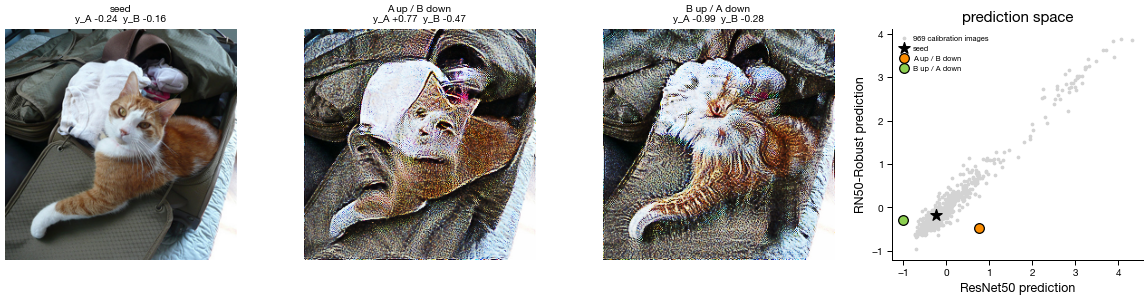

In [5]:
from pnc.utils import load_encoding_pickle
pa, pb = load_encoding_pickle(MONKEY, UNIT, MODEL_A), load_encoding_pickle(MONKEY, UNIT, MODEL_B)
natA = (pa['PCA_resp'] @ pa['readout_vec'] + pa['readout_bias']).numpy()   # each model's predictions of the 969 calibration images
natB = (pb['PCA_resp'] @ pb['readout_vec'] + pb['readout_bias']).numpy()

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
axes[0].imshow(U.to_display(seed)); axes[0].set_title(f'seed\ny_A {ya0:+.2f}  y_B {yb0:+.2f}', fontsize=8)
for ax, (tag, r) in zip(axes[1:3], pair.items()):
    ax.imshow(U.to_display(r['image'])); ax.set_title(f'{tag}\ny_A {r["ya"]:+.2f}  y_B {r["yb"]:+.2f}', fontsize=8)
for ax in axes[:3]:
    ax.set_axis_off()
ax = axes[3]
ax.scatter(natA, natB, s=4, color='lightgray', label='969 calibration images')
ax.scatter([ya0], [yb0], marker='*', s=90, color='k', label='seed')
cols = [get_model_color(MODEL_A), get_model_color(MODEL_B)]
for (tag, r), c in zip(pair.items(), cols):
    ax.scatter([r['ya']], [r['yb']], s=60, color=c, edgecolor='k', label=tag)
ax.set(xlabel=f'{MODEL_SHORT_NAMES[MODEL_A]} prediction', ylabel=f'{MODEL_SHORT_NAMES[MODEL_B]} prediction', title='prediction space')
ax.legend(fontsize=6); plt.tight_layout(); plt.show()

## 4. The production stimuli for this site

`source_data/stimuli_controversial/results_12-01-2025/` holds the 140 images shown to Monkey R
(`controversial_max_r50_...` = ResNet-50-preferring, `controversial_max_robust_...` = robust-preferring); the file
names carry both models' synthesis scores (`srobust`, `sr50`, in the units of the Dec-2024 Lasso readouts).

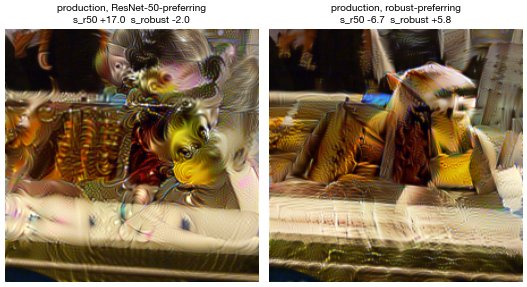

FeatureFetcher hooks all freed
FeatureFetcher hooks all freed


In [6]:
from PIL import Image
import re
d = paths.source_data() / 'stimuli_controversial' / 'results_12-01-2025'
def prod(direction):
    hits = sorted(d.glob(f'controversial_max_{direction}_*_unit_{UNIT}_img_{SEED_IDX}_*.png'))
    return hits[0] if hits else None
fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, direction, label in zip(axes, ['r50', 'robust'], ['ResNet-50-preferring', 'robust-preferring']):
    p = prod(direction)
    if p is None:
        ax.set_title(f'{label}: not shipped'); ax.set_axis_off(); continue
    m = re.search(r'srobust_(-?\d+(?:\.\d+)?)_sr50_(-?\d+(?:\.\d+)?)', p.name)   # both synthesis scores live in the file name
    ax.imshow(Image.open(p).convert('RGB')); ax.set_axis_off()
    ax.set_title(f'production, {label}\ns_r50 {float(m.group(2)):+.1f}  s_robust {float(m.group(1)):+.1f}', fontsize=8)
plt.tight_layout(); plt.show()
objA.close(); objB.close()